In [3]:
import re
import csv

def parse_mmlu_file(txt_file, output_csv):
    data = []
    with open(txt_file, 'r') as f:
        for line in f:
            match = re.search(r'\|\s*(.*?)\s*\|.*?\|([0-9.]+)\|±\s*\|([0-9.]+)\|', line)
            if match:
                category = match.group(1).strip('- ').strip().replace('_', ' ').title().replace('Mmlu', 'MMLU').replace('Stem', 'STEM')
                acc = float(match.group(2))
                se = float(match.group(3))
                data.append([category, acc, se])
    #data.sort()
    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['category', 'accuracy', 'std_error'])
        writer.writerows(data)

parse_mmlu_file("llama-mmlu.txt", "llama-mmlu.csv")
parse_mmlu_file("smileyllama-525-mmlu.txt", "smileyllama-525-mmlu.csv")
parse_mmlu_file("llama-base-mmlu.txt", "llama-base-mmlu.csv")

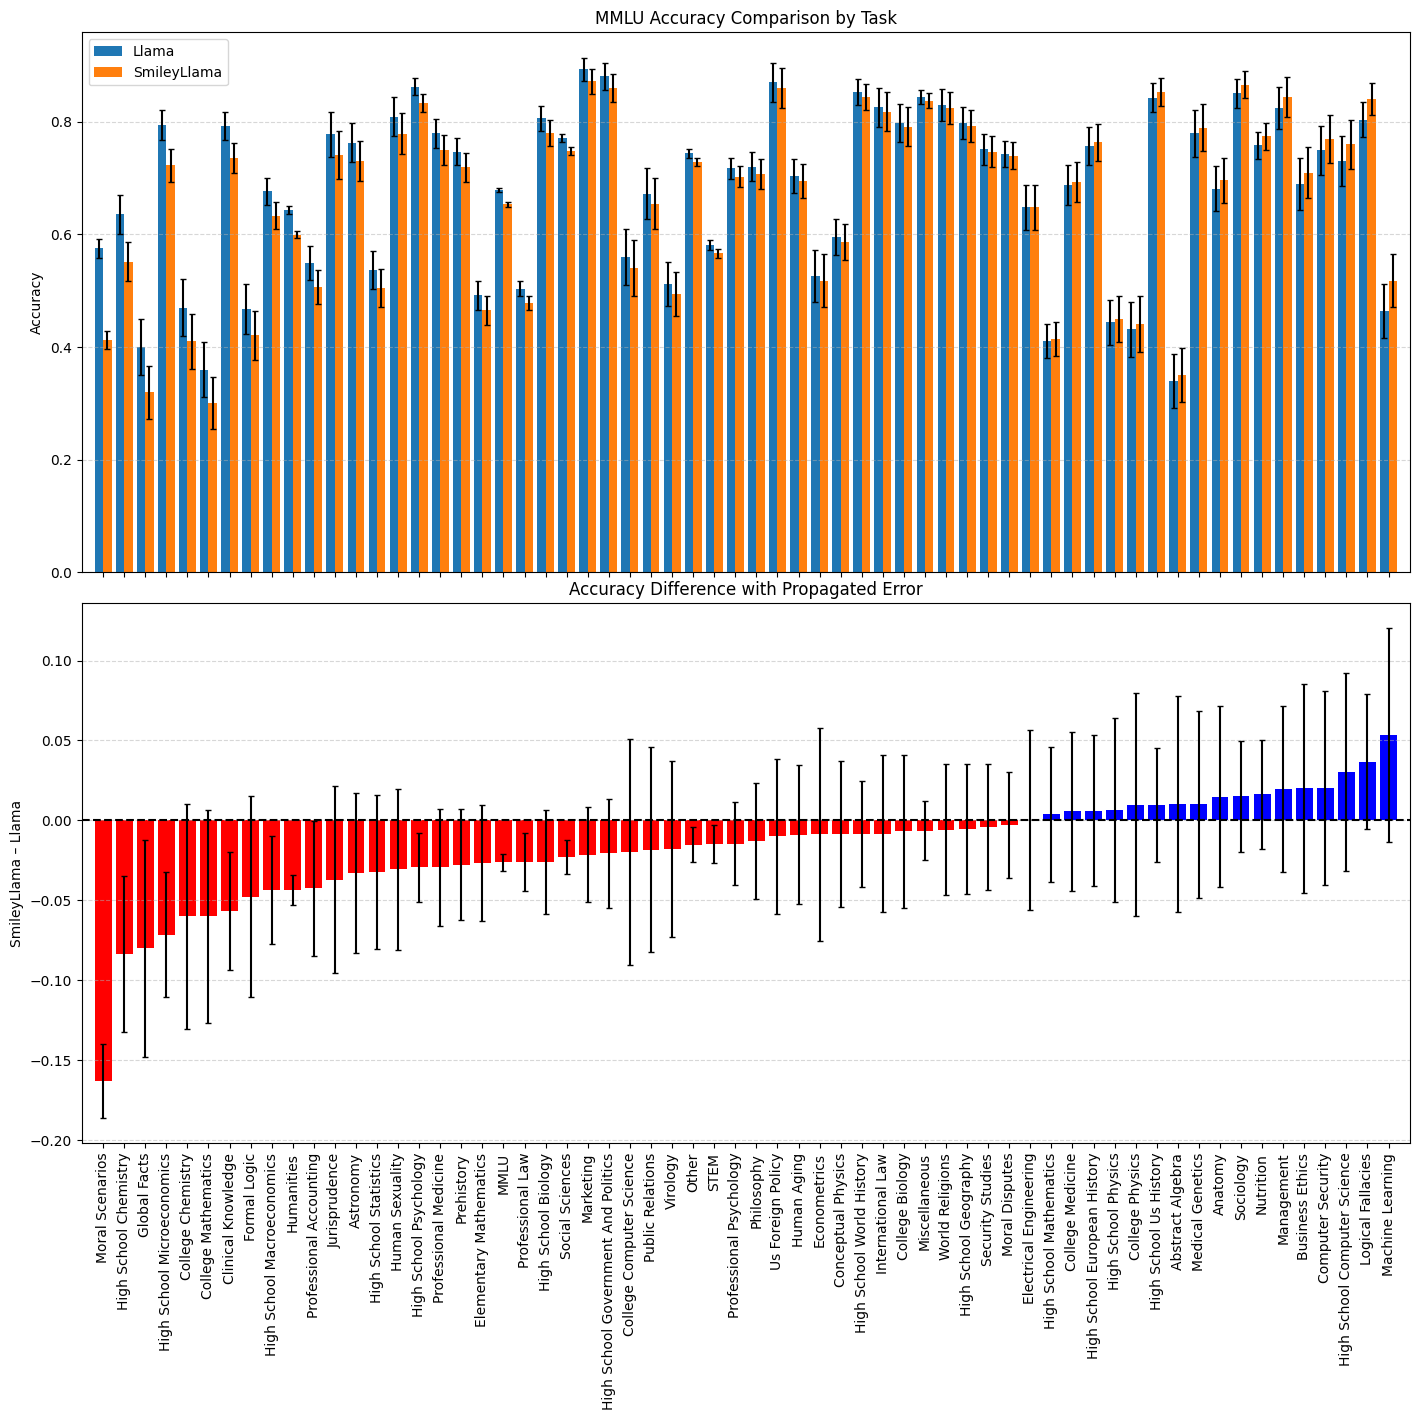

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df1 = pd.read_csv("llama-mmlu.csv")
df2 = pd.read_csv("smileyllama-525-mmlu.csv")
df3 = pd.read_csv("llama-base-mmlu.csv")

# Merge on category
merged = pd.merge(df1, df2, on='category', suffixes=('_model1', '_model2'))

# Sort by model1 accuracy or difference
merged['diff'] = merged['accuracy_model2'] - merged['accuracy_model1']
merged['se_diff'] = np.sqrt(merged['std_error_model1']**2 + merged['std_error_model2']**2)

# Sort by difference (optional)
merged = merged.sort_values(by='diff')

# X-axis positions
x = np.arange(len(merged))
width = 0.4

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 14), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

# --- Top: Model 1 and Model 2 Accuracy ---
axs[0].bar(x - width/2, merged['accuracy_model1'], width, yerr=merged['std_error_model1'], label='Llama', capsize=2)
axs[0].bar(x + width/2, merged['accuracy_model2'], width, yerr=merged['std_error_model2'], label='SmileyLlama', capsize=2)
axs[0].set_ylabel("Accuracy")
axs[0].set_title("MMLU Accuracy Comparison by Task")
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
axs[0].margins(x=0.01)

# --- Middle: Difference ---
for i, (diff, se) in enumerate(zip(merged['diff'], merged['se_diff'])):
    color = 'blue' if diff > 0 else 'red'
    axs[1].bar(x[i], diff, yerr=se, capsize=2, color=color)

axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_ylabel("SmileyLlama – Llama")
axs[1].set_title("Accuracy Difference with Propagated Error")
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
axs[1].set_xticks(x)
axs[1].set_xticklabels(merged['category'], rotation=90, fontsize=10)
axs[1].margins(x=0.01)

plt.tight_layout(pad=0)
plt.savefig("mmlu_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

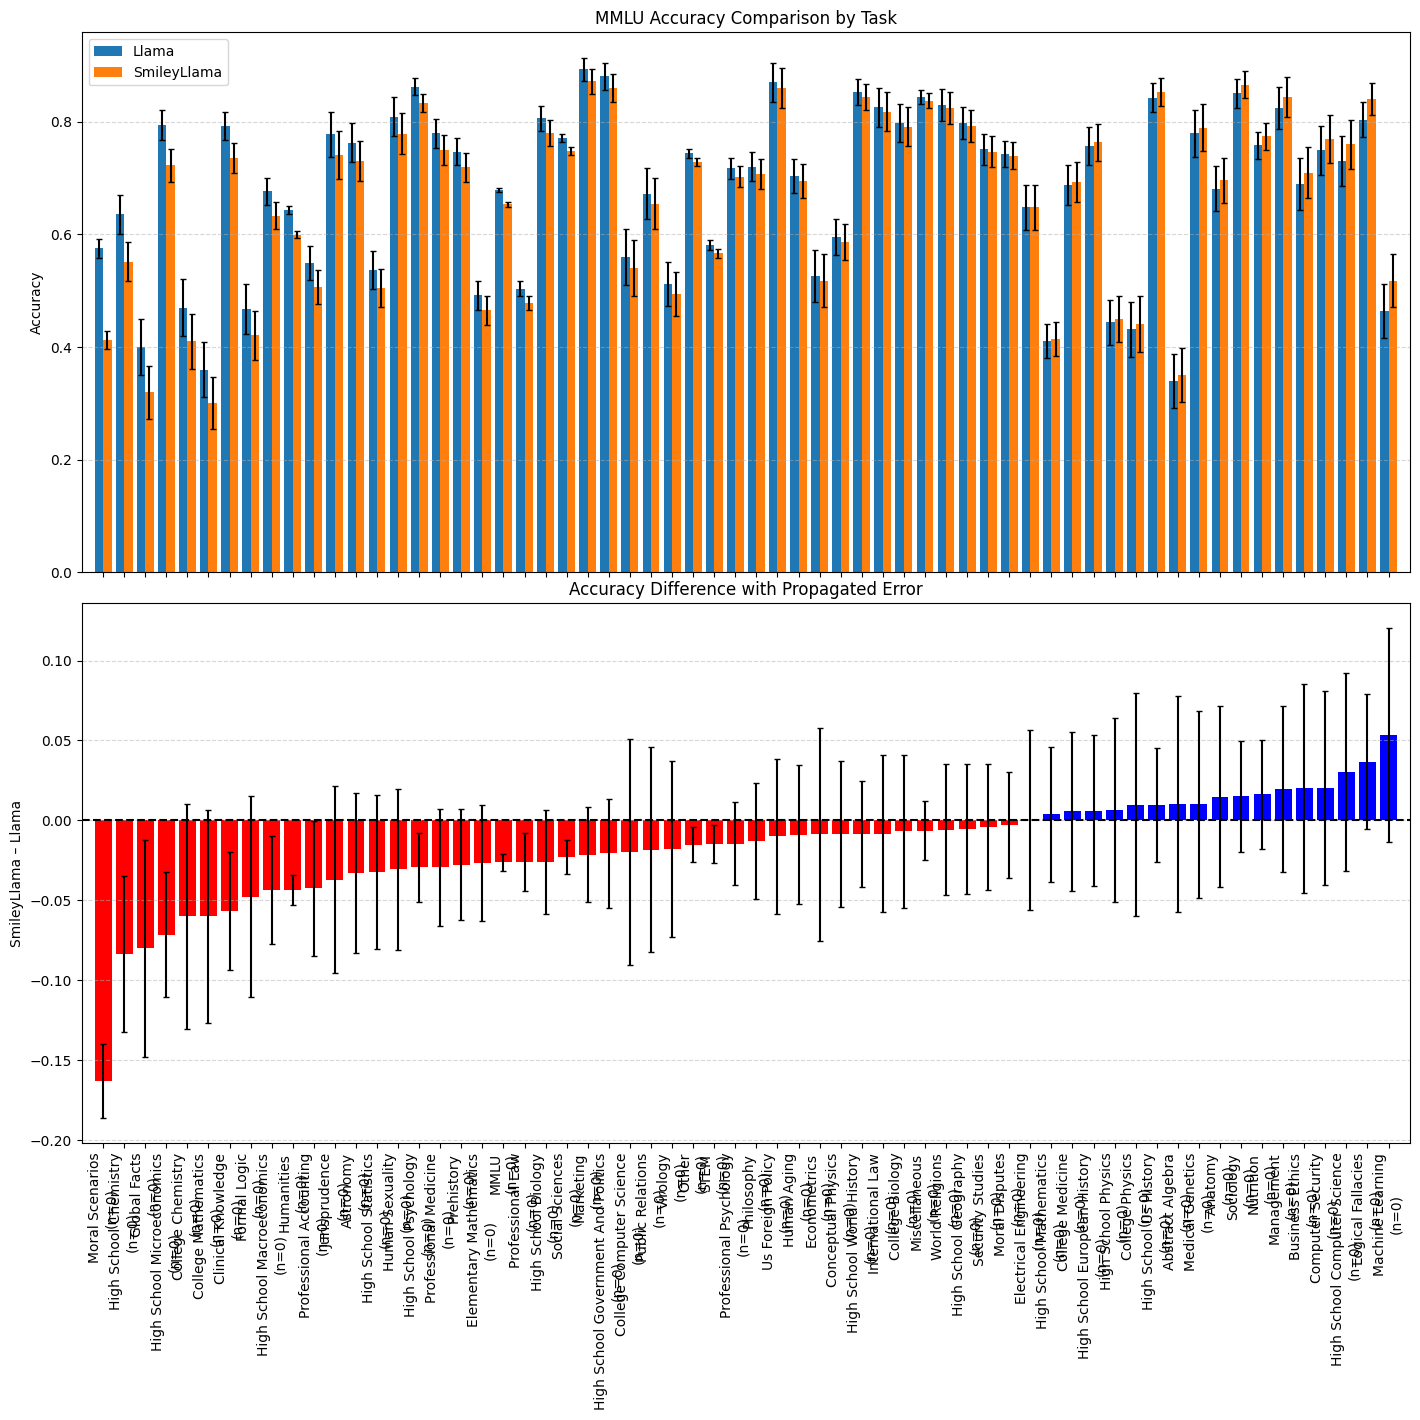

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extracted N-values from your lm-evaluation-harness log
n_values = {
    'high_school_biology': 310, 'abstract_algebra': 100, 'elementary_mathematics': 378,
    'conceptual_physics': 235, 'high_school_chemistry': 203, 'computer_security': 100,
    'electrical_engineering': 145, 'anatomy': 135, 'high_school_mathematics': 270,
    'college_physics': 102, 'college_biology': 144, 'machine_learning': 112,
    'high_school_statistics': 216, 'high_school_physics': 151, 'college_chemistry': 100,
    'astronomy': 152, 'college_computer_science': 100, 'college_mathematics': 100,
    'high_school_computer_science': 100, 'clinical_knowledge': 265, 'professional_medicine': 272,
    'business_ethics': 100, 'global_facts': 100, 'human_aging': 223, 'marketing': 234,
    'nutrition': 306, 'college_medicine': 173, 'medical_genetics': 100, 'management': 103,
    'professional_accounting': 282, 'miscellaneous': 783, 'virology': 166,
    'high_school_psychology': 545, 'security_studies': 245, 'high_school_geography': 198,
    'high_school_microeconomics': 238, 'sociology': 201, 'high_school_government_and_politics': 193,
    'high_school_macroeconomics': 390, 'econometrics': 114, 'public_relations': 110,
    'professional_psychology': 612, 'us_foreign_policy': 100, 'human_sexuality': 131,
    'jurisprudence': 108, 'high_school_us_history': 204, 'international_law': 121,
    'moral_disputes': 346, 'formal_logic': 126, 'high_school_world_history': 237,
    'world_religions': 171, 'philosophy': 311, 'prehistory': 324, 'logical_fallacies': 163,
    'professional_law': 1534, 'moral_scenarios': 895, 'high_school_european_history': 165
}

# Load data
df1 = pd.read_csv("llama-mmlu.csv")
df2 = pd.read_csv("smileyllama-525-mmlu.csv")
df3 = pd.read_csv("llama-base-mmlu.csv") # Loaded but currently unused 

# Merge on category
merged = pd.merge(df1, df2, on='category', suffixes=('_model1', '_model2'))

# Sort by model1 accuracy or difference
merged['diff'] = merged['accuracy_model2'] - merged['accuracy_model1']
merged['se_diff'] = np.sqrt(merged['std_error_model1']**2 + merged['std_error_model2']**2)

# Sort by difference
merged = merged.sort_values(by='diff')

# --- NEW: Map N-values to create a descriptive x-axis label ---
# Strip 'mmlu_' prefix just in case your CSV uses it, ensuring the map works cleanly
merged['clean_cat'] = merged['category'].str.replace('mmlu_', '')
merged['n'] = merged['clean_cat'].map(n_values)

# Create the label: "category_name \n (n=XXX)"
merged['label_with_n'] = merged['category'] + '\n(n=' + merged['n'].fillna(0).astype(int).astype(str) + ')'

# X-axis positions
x = np.arange(len(merged))
width = 0.4

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 14), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

# --- Top: Model 1 and Model 2 Accuracy ---
axs[0].bar(x - width/2, merged['accuracy_model1'], width, yerr=merged['std_error_model1'], label='Llama', capsize=2)
axs[0].bar(x + width/2, merged['accuracy_model2'], width, yerr=merged['std_error_model2'], label='SmileyLlama', capsize=2)
axs[0].set_ylabel("Accuracy")
axs[0].set_title("MMLU Accuracy Comparison by Task")
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
axs[0].margins(x=0.01)

# --- Middle: Difference ---
for i, (diff, se) in enumerate(zip(merged['diff'], merged['se_diff'])):
    color = 'blue' if diff > 0 else 'red'
    axs[1].bar(x[i], diff, yerr=se, capsize=2, color=color)

axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_ylabel("SmileyLlama – Llama")
axs[1].set_title("Accuracy Difference with Propagated Error")
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
axs[1].set_xticks(x)

# --- UPDATED: Apply the new label containing the n-value ---
axs[1].set_xticklabels(merged['label_with_n'], rotation=90, fontsize=10)
axs[1].margins(x=0.01)

plt.tight_layout(pad=0)
plt.savefig("mmlu_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

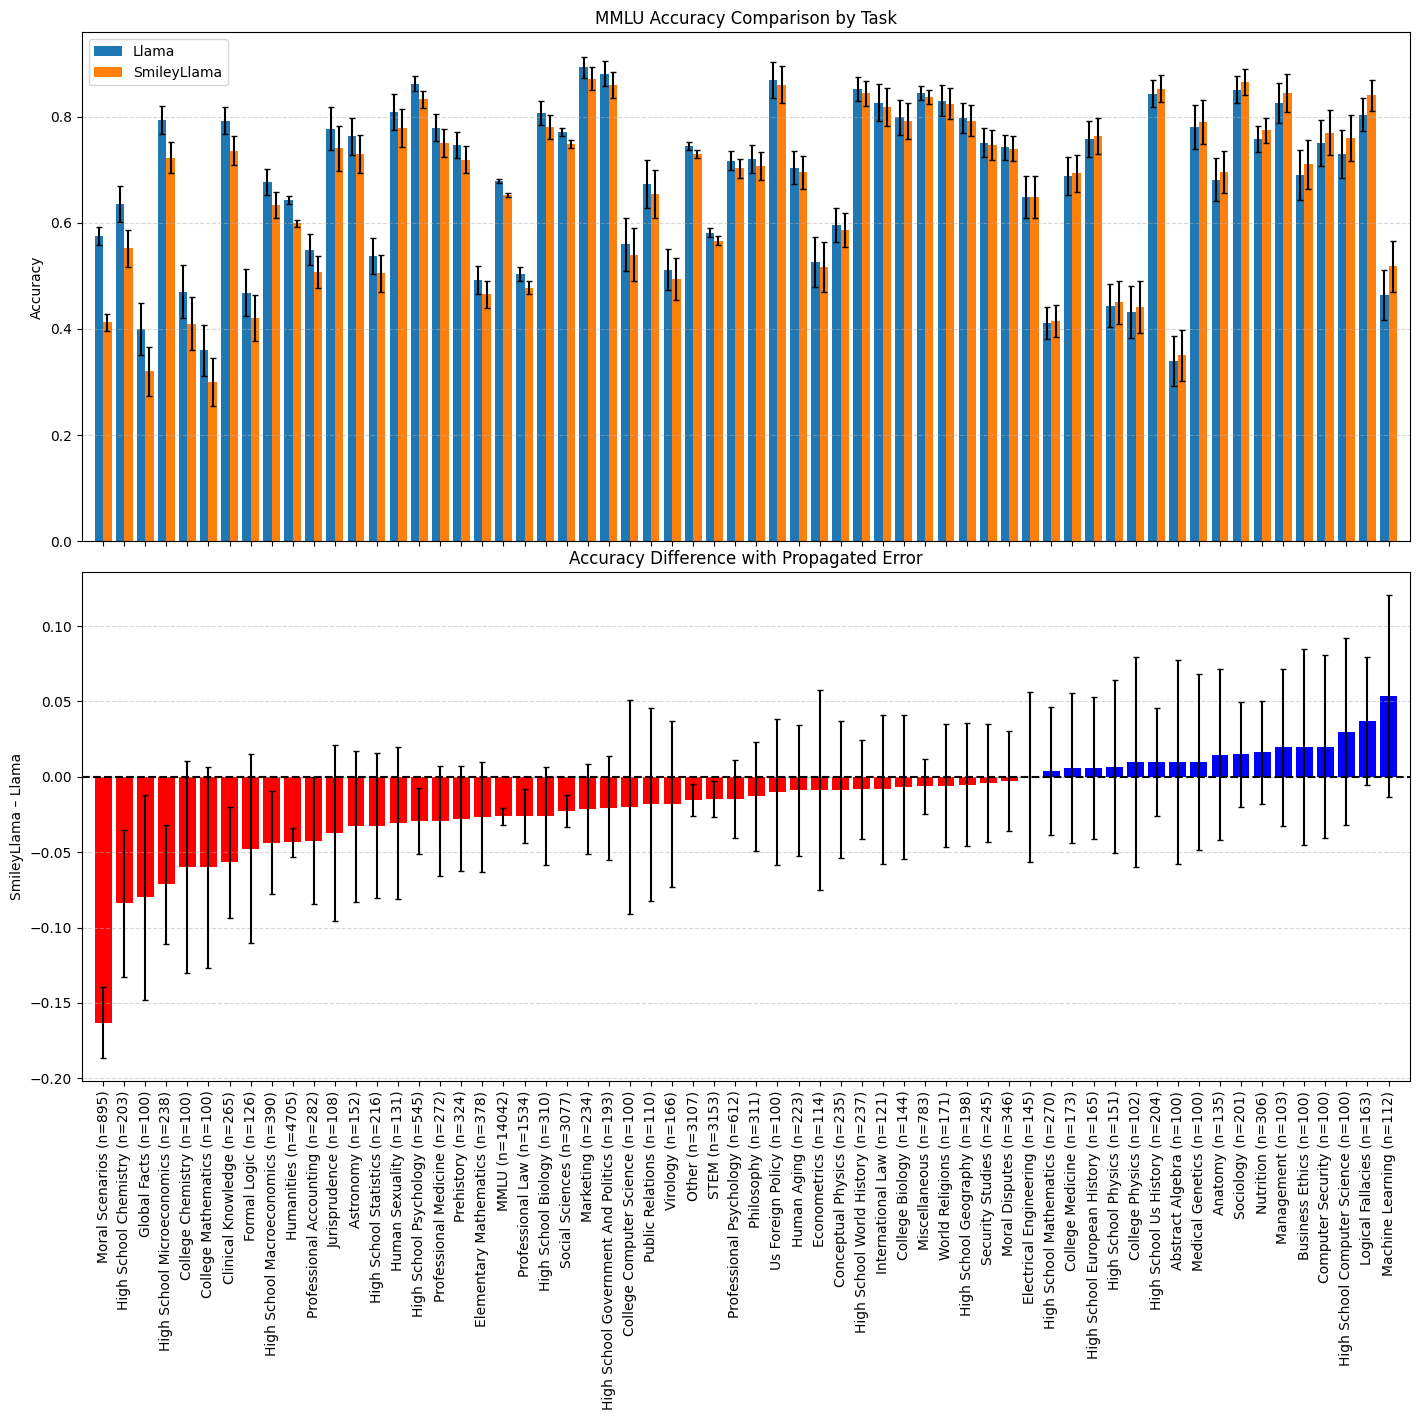

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df1 = pd.read_csv("llama-mmlu.csv")
df2 = pd.read_csv("smileyllama-525-mmlu.csv")
# df3 = pd.read_csv("llama-base-mmlu.csv") # Loaded but currently unused

# Merge on category
merged = pd.merge(df1, df2, on='category', suffixes=('_model1', '_model2'))

# Sort by difference
merged['diff'] = merged['accuracy_model2'] - merged['accuracy_model1']
merged['se_diff'] = np.sqrt(merged['std_error_model1']**2 + merged['std_error_model2']**2)
merged = merged.sort_values(by='diff')

# --- Find the n column from the CSVs ---
if 'n' in merged.columns:
    n_col = merged['n']
elif 'n_model1' in merged.columns:
    n_col = merged['n_model1']
elif 'n_model2' in merged.columns:
    n_col = merged['n_model2']
else:
    raise KeyError("Could not find the 'n' column. Please ensure it exists in at least one of the loaded CSVs.")

# Create the label: "Category \n (n=XXX)"
merged['label_with_n'] = merged['category'] + ' (n=' + n_col.fillna(0).astype(int).astype(str) + ')'

# X-axis positions
x = np.arange(len(merged))
width = 0.4

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 14), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

# --- Top: Model 1 and Model 2 Accuracy ---
axs[0].bar(x - width/2, merged['accuracy_model1'], width, yerr=merged['std_error_model1'], label='Llama', capsize=2)
axs[0].bar(x + width/2, merged['accuracy_model2'], width, yerr=merged['std_error_model2'], label='SmileyLlama', capsize=2)
axs[0].set_ylabel("Accuracy")
axs[0].set_title("MMLU Accuracy Comparison by Task")
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
axs[0].margins(x=0.01)

# --- Middle: Difference ---
for i, (diff, se) in enumerate(zip(merged['diff'], merged['se_diff'])):
    color = 'blue' if diff > 0 else 'red'
    axs[1].bar(x[i], diff, yerr=se, capsize=2, color=color)

axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_ylabel("SmileyLlama – Llama")
axs[1].set_title("Accuracy Difference with Propagated Error")
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
axs[1].set_xticks(x)

# Apply the new labels containing the n-values
axs[1].set_xticklabels(merged['label_with_n'], rotation=90, fontsize=10)
axs[1].margins(x=0.01)

plt.tight_layout(pad=0)
plt.savefig("mmlu_comparison.pdf", dpi=600, bbox_inches='tight')
plt.show()